# 🌍 Hackathon IndabaX Cameroon 2026 - Air Quality Prediction Starter Kit

**Thème:** L'IA au service de la résilience climatique et sanitaire au Cameroun

---
## Objectifs de ce Notebook

Ce notebook vous guide à travers les étapes essentielles pour construire un modèle prédictif de base de qualité de l'air :

1. **Exploration des données** (EDA)
2. **Feature Engineering** climatique
3. **Modélisation baseline** (Random Forest + XGBoost)
4. **Visualisations** pour dashboard
5. **Système d'alerte** (bonus)

---

## Rappel des Outputs Attendus

- **Output 1:** Script/Notebook de prédiction documenté ✅ (ce fichier)
- **Output 2:** Dashboard interactif (fichier `dashboard_template.py` séparé)
- **Output 3:** Pitch Deck + Vidéo démo (3 min max)

---

## 🌐 Téléchargement des Données Open-Meteo

**SOURCE:** Les données proviennent de l'API Open-Meteo (gratuite, open-source)

**OPTIONS:**
1. **Option A (Recommandée):** Télécharger automatiquement via API (voir ci-dessous)
2. **Option B:** Si vous avez déjà le dataset Kaggle, uploadez les fichiers `train.csv` et `test.csv`

---

### Option A: Téléchargement Automatique Open-Meteo

**Étapes:**
1. Exécutez la cellule ci-dessous pour définir les fonctions
2. Choisissez entre test rapide ou dataset complet
3. Les données seront automatiquement formatées

In [2]:
# ==================== FONCTIONS DE TÉLÉCHARGEMENT OPEN-METEO ====================

import requests
import time
import warnings
warnings.filterwarnings('ignore')

# Villes du Cameroun
CITIES_CAMEROON = {
    'Douala': {'lat': 4.05, 'lon': 9.70},
    'Yaounde': {'lat': 3.87, 'lon': 11.52},
    'Bafoussam': {'lat': 5.48, 'lon': 10.42},
    'Bertoua': {'lat': 4.58, 'lon': 13.68},
    'Ebolowa': {'lat': 2.90, 'lon': 11.15},
    'Bamenda': {'lat': 5.96, 'lon': 10.15},
    'Buea': {'lat': 4.16, 'lon': 9.24},
    'Ngaoundere': {'lat': 7.32, 'lon': 13.58},
    'Maroua': {'lat': 10.59, 'lon': 14.32},
    'Garoua': {'lat': 9.30, 'lon': 13.40}
}

def fetch_weather_data(lat, lon, start_date, end_date):
    """Récupère données météorologiques depuis Open-Meteo Archive API."""
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": start_date,
        "end_date": end_date,
        "hourly": [
            "temperature_2m", "relative_humidity_2m", "dewpoint_2m",
            "precipitation", "pressure_msl", "surface_pressure",
            "cloudcover", "windspeed_10m", "winddirection_10m",
            "windgusts_10m", "is_day"
        ],
        "timezone": "Africa/Douala"
    }
    try:
        response = requests.get(url, params=params, timeout=30)
        response.raise_for_status()
        data = response.json()
        return data if 'hourly' in data else None
    except Exception as e:
        print(f"⚠️ Erreur météo: {e}")
        return None

def fetch_air_quality_data(lat, lon, start_date, end_date):
    """Récupère données qualité de l'air depuis Open-Meteo Air Quality API."""
    url = "https://air-quality-api.open-meteo.com/v1/air-quality"
    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": start_date,
        "end_date": end_date,
        "hourly": [
            "pm10", "pm2_5", "carbon_monoxide", "nitrogen_dioxide",
            "sulphur_dioxide", "ozone", "dust", "uv_index",
            "european_aqi", "us_aqi"
        ],
        "timezone": "Africa/Douala"
    }
    try:
        response = requests.get(url, params=params, timeout=30)
        response.raise_for_status()
        data = response.json()
        return data if 'hourly' in data else None
    except Exception as e:
        print(f"⚠️ Erreur air quality: {e}")
        return None

def download_city_data(city_name, coords, start_date, end_date):
    """Télécharge et combine données météo + air quality pour une ville."""
    import pandas as pd

    print(f"📍 {city_name}...", end=' ')

    # Météo
    weather_data = fetch_weather_data(coords['lat'], coords['lon'], start_date, end_date)
    if not weather_data:
        print("❌")
        return None

    time.sleep(1)  # Rate limiting

    # Air quality
    airquality_data = fetch_air_quality_data(coords['lat'], coords['lon'], start_date, end_date)
    time.sleep(1)

    # Créer DataFrame météo
    df = pd.DataFrame({
        'date': pd.to_datetime(weather_data['hourly']['time']),
        'city': city_name,
        'latitude': coords['lat'],
        'longitude': coords['lon'],
        'temperature_2m': weather_data['hourly']['temperature_2m'],
        'humidity': weather_data['hourly']['relative_humidity_2m'],
        'dewpoint_2m': weather_data['hourly']['dewpoint_2m'],
        'precipitation': weather_data['hourly']['precipitation'],
        'pressure_msl': weather_data['hourly']['pressure_msl'],
        'surface_pressure': weather_data['hourly']['surface_pressure'],
        'cloudcover': weather_data['hourly']['cloudcover'],
        'windspeed_10m': weather_data['hourly']['windspeed_10m'],
        'winddirection_10m': weather_data['hourly']['winddirection_10m'],
        'windgusts_10m': weather_data['hourly']['windgusts_10m'],
        'is_day': weather_data['hourly']['is_day']
    })

    # Ajouter air quality 
    if airquality_data and 'hourly' in airquality_data:
        air_df = pd.DataFrame({
            'date': pd.to_datetime(airquality_data['hourly']['time']),
            'pm10': airquality_data['hourly'].get('pm10'),
            'pm2_5': airquality_data['hourly'].get('pm2_5'),
            'carbon_monoxide': airquality_data['hourly'].get('carbon_monoxide'),
            'nitrogen_dioxide': airquality_data['hourly'].get('nitrogen_dioxide'),
            'sulphur_dioxide': airquality_data['hourly'].get('sulphur_dioxide'),
            'ozone': airquality_data['hourly'].get('ozone'),
            'dust': airquality_data['hourly'].get('dust'),
            'uv_index': airquality_data['hourly'].get('uv_index'),
            'european_aqi': airquality_data['hourly'].get('european_aqi'),
            'us_aqi': airquality_data['hourly'].get('us_aqi')
        })
        df = df.merge(air_df, on='date', how='left')

    print(f"✅ {len(df):,} lignes")
    return df

def download_cameroon_dataset(cities_dict, start_date, end_date):
    """Télécharge le dataset complet pour plusieurs villes."""
    import pandas as pd

    print(f"\n{'='*70}")
    print(f"🌍 TÉLÉCHARGEMENT DONNÉES CAMEROUN")
    print(f"📅 Période: {start_date} à {end_date}")
    print(f"🏙️  Villes: {len(cities_dict)}")
    print(f"{'='*70}\n")

    all_data = []
    for city_name, coords in cities_dict.items():
        df_city = download_city_data(city_name, coords, start_date, end_date)
        if df_city is not None:
            all_data.append(df_city)

    if all_data:
        df_final = pd.concat(all_data, ignore_index=True)
        df_final = df_final.sort_values(['date', 'city']).reset_index(drop=True)
        print(f"\n{'='*70}")
        print(f"✅ Dataset créé: {len(df_final):,} lignes × {len(df_final.columns)} colonnes")
        print(f"📅 Période: {df_final['date'].min()} à {df_final['date'].max()}")
        print(f"{'='*70}\n")
        return df_final
    return None

print("✅ Fonctions de téléchargement chargées!")

✅ Fonctions de téléchargement chargées!


### 🧪 Test Rapide: 1 ville, 1 semaine

In [3]:
# TEST RAPIDE (décommentez pour tester)
df_test = download_city_data('Douala', CITIES_CAMEROON['Douala'], '2024-01-01', '2024-01-07')
print(df_test.head())
print(df_test.info())

📍 Douala... ✅ 168 lignes
                 date    city  latitude  longitude  temperature_2m  humidity  \
0 2024-01-01 00:00:00  Douala      4.05        9.7            26.2        92   
1 2024-01-01 01:00:00  Douala      4.05        9.7            26.0        92   
2 2024-01-01 02:00:00  Douala      4.05        9.7            25.7        94   
3 2024-01-01 03:00:00  Douala      4.05        9.7            25.2        96   
4 2024-01-01 04:00:00  Douala      4.05        9.7            24.8        98   

   dewpoint_2m  precipitation  pressure_msl  surface_pressure  ...  pm10  \
0         24.8            0.0        1012.6            1010.6  ...  37.1   
1         24.6            0.0        1012.4            1010.4  ...  41.4   
2         24.6            0.0        1011.4            1009.4  ...  43.2   
3         24.6            0.0        1011.1            1009.1  ...  44.1   
4         24.5            0.0        1011.0            1009.0  ...  44.2   

   pm2_5  carbon_monoxide  nitrogen_d

### 📊 Téléchargement Complet: Toutes les villes

**⚠️ ATTENTION:** Cela prendra 5-10 minutes pour télécharger 3 ans de données pour 10 villes.

**Options:**
- **Test court:** 2024 uniquement (rapide)
- **Dataset complet:** 2022-2024 (recommandé pour hackathon)

In [4]:
# OPTION 1: Test court (2024 uniquement) - ~2 minutes
df_train = download_cameroon_dataset(
    CITIES_CAMEROON,
    start_date='2024-01-01',
    end_date='2024-10-31'
)

# OPTION 2: Dataset complet (2022-2024) - ~5-10 minutes
# Décommentez ci-dessous pour télécharger le dataset complet
# df_train = download_cameroon_dataset(
#     CITIES_CAMEROON,
#     start_date='2022-01-01',
#     end_date='2024-10-31'
# )


🌍 TÉLÉCHARGEMENT DONNÉES CAMEROUN
📅 Période: 2024-01-01 à 2024-10-31
🏙️  Villes: 10

📍 Douala... ✅ 7,320 lignes
📍 Yaounde... ✅ 7,320 lignes
📍 Bafoussam... ✅ 7,320 lignes
📍 Bertoua... ✅ 7,320 lignes
📍 Ebolowa... ✅ 7,320 lignes
📍 Bamenda... ✅ 7,320 lignes
📍 Buea... ✅ 7,320 lignes
📍 Ngaoundere... ✅ 7,320 lignes
📍 Maroua... ✅ 7,320 lignes
📍 Garoua... ✅ 7,320 lignes

✅ Dataset créé: 73,200 lignes × 25 colonnes
📅 Période: 2024-01-01 00:00:00 à 2024-10-31 23:00:00



### 💾 Sauvegarder les Données (Optionnel)

In [5]:
# Sauvegarder en CSV
if df_train is not None:
    df_train.to_csv('cameroon_air_quality_train.csv', index=False)
    print("✅ Données sauvegardées: cameroon_air_quality_train.csv")

    # Pour télécharger depuis Colab
    # from google.colab import files
    # files.download('cameroon_air_quality_train.csv')

✅ Données sauvegardées: cameroon_air_quality_train.csv


### Option B: Charger depuis un fichier existant

In [ ]:
# Si vous avez déjà téléchargé les données
# df_train = pd.read_csv('train.csv')
# df_test = pd.read_csv('test.csv')

# OU depuis Kaggle
# !kaggle competitions download -c cameroon-air-quality-prediction
# !unzip cameroon-air-quality-prediction.zip

In [6]:
# Imports standards
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from datetime import datetime, timedelta

# Machine Learning
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# XGBoost (modèle avancé)
try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print("⚠️ XGBoost non installé. Installez-le avec: pip install xgboost")

# Visualisations interactives
try:
    import plotly.express as px
    import plotly.graph_objects as go
    PLOTLY_AVAILABLE = True
except ImportError:
    PLOTLY_AVAILABLE = False
    print("⚠️ Plotly non installé. Installez-le avec: pip install plotly")

# Configuration
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ Imports réussis!")

✅ Imports réussis!


## 📂 Chargement des Données

**Instructions:**
1. Téléchargez le dataset depuis Kaggle
2. Placez les fichiers dans le même dossier que ce notebook
3. Adaptez les noms de fichiers ci-dessous

# À ADAPTER selon vos noms de fichiers
TRAIN_FILE = 'train.csv'  # Fichier d'entraînement
TEST_FILE = 'test.csv'    # Fichier de test

try:
    df_train = pd.read_csv(TRAIN_FILE)
    df_test = pd.read_csv(TEST_FILE)
    print(f"✅ Données chargées avec succès!")
    print(f"   - Train: {df_train.shape[0]:,} lignes × {df_train.shape[1]} colonnes")
    print(f"   - Test:  {df_test.shape[0]:,} lignes × {df_test.shape[1]} colonnes")
except FileNotFoundError:
    print("❌ Fichiers non trouvés. Créez des données synthétiques pour tester...")

    # Génération de données synthétiques pour démo
    np.random.seed(42)
    n_samples = 5000
    dates = pd.date_range('2020-01-01', periods=n_samples, freq='H')

    df_train = pd.DataFrame({
        'date': dates[:4000],
        'temperature': np.random.uniform(20, 35, 4000),
        'humidity': np.random.uniform(40, 90, 4000),
        'wind_speed': np.random.uniform(0, 15, 4000),
        'pressure': np.random.uniform(1000, 1020, 4000),
        'pm25': np.random.uniform(10, 150, 4000)  # Target variable
    })

    df_test = pd.DataFrame({
        'date': dates[4000:],
        'temperature': np.random.uniform(20, 35, 1000),
        'humidity': np.random.uniform(40, 90, 1000),
        'wind_speed': np.random.uniform(0, 15, 1000),
        'pressure': np.random.uniform(1000, 1020, 1000)
    })

    print("✅ Données synthétiques créées pour démonstration")

In [8]:
# Aperçu des données
print("\n📊 Aperçu du dataset d'entraînement:")
display(df_train.head())

print("\n📋 Informations sur les colonnes:")
print(df_train.info())

print("\n📈 Statistiques descriptives:")
display(df_train.describe())


📊 Aperçu du dataset d'entraînement:


,date,temperature,humidity,wind_speed,pressure,pm25
0,2020-01-01 00:00:00,25.618102,68.599794,10.804019,1013.086126,10.616225
1,2020-01-01 01:00:00,34.260715,80.271616,10.309245,1001.600651,10.046222
2,2020-01-01 02:00:00,30.979909,78.008046,1.436313,1004.846596,76.116885
3,2020-01-01 03:00:00,28.979877,47.694995,13.838586,1015.473587,14.101119
4,2020-01-01 04:00:00,22.340280,47.462473,8.527083,1010.573717,146.434558



📋 Informations sur les colonnes:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         4000 non-null   datetime64[ns]
 1   temperature  4000 non-null   float64       
 2   humidity     4000 non-null   float64       
 3   wind_speed   4000 non-null   float64       
 4   pressure     4000 non-null   float64       
 5   pm25         4000 non-null   float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 187.6 KB
None

📈 Statistiques descriptives:


,date,temperature,humidity,wind_speed,pressure,pm25
count,4000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,2020-03-24 07:29:59.999999744,27.462705,64.603116,7.478381,1009.934616,81.660128
min,2020-01-01 00:00:00,20.000175,40.001536,0.000792,1000.006195,10.035344
25%,2020-02-11 15:45:00,23.657942,52.146591,3.793464,1004.824524,47.773044
50%,2020-03-24 07:30:00,27.507535,64.321186,7.425291,1009.827589,82.346739
75%,2020-05-04 23:15:00,31.249472,76.927040,11.205992,1015.121082,115.239222
max,2020-06-15 15:00:00,34.995765,89.973034,14.995098,1019.998497,149.982001
std,NaN,4.355503,14.381145,4.302132,5.810445,40.170527


## 🔍 1. EXPLORATION DES DONNÉES (EDA)

### 1.1 Analyse des Valeurs Manquantes

In [9]:
def analyze_missing_values(df, title="Dataset"):
    """Analyse et visualise les valeurs manquantes."""
    missing = df.isnull().sum()
    missing_pct = 100 * missing / len(df)

    missing_df = pd.DataFrame({
        'Colonnes': missing.index,
        'Valeurs Manquantes': missing.values,
        'Pourcentage (%)': missing_pct.values
    })
    missing_df = missing_df[missing_df['Valeurs Manquantes'] > 0].sort_values('Pourcentage (%)', ascending=False)

    if len(missing_df) > 0:
        print(f"\n⚠️ Valeurs manquantes dans {title}:")
        display(missing_df)

        # Visualisation
        plt.figure(figsize=(10, 5))
        plt.barh(missing_df['Colonnes'], missing_df['Pourcentage (%)'], color='coral')
        plt.xlabel('Pourcentage de valeurs manquantes (%)')
        plt.title(f'Distribution des valeurs manquantes - {title}')
        plt.tight_layout()
        plt.show()
    else:
        print(f"✅ Aucune valeur manquante dans {title}!")

analyze_missing_values(df_train, "Train")
analyze_missing_values(df_test, "Test")

✅ Aucune valeur manquante dans Train!
✅ Aucune valeur manquante dans Test!


### 1.2 Distribution de la Variable Cible (PM2.5)

**Seuils OMS pour PM2.5:**
- **Bon:** < 15 μg/m³
- **Modéré:** 15-35 μg/m³
- **Mauvais:** 35-55 μg/m³
- **Très mauvais:** > 55 μg/m³

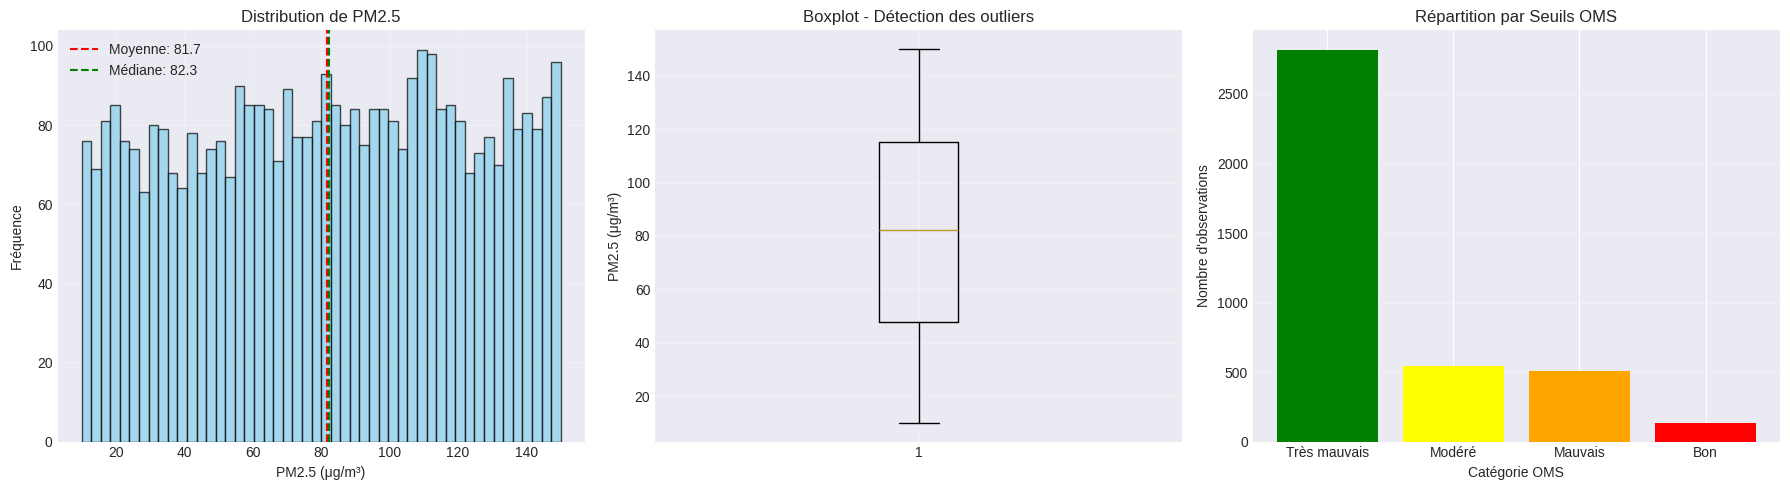


📊 Statistiques PM2.5:
   - Moyenne: 81.66 μg/m³
   - Médiane: 82.35 μg/m³
   - Écart-type: 40.17 μg/m³
   - Min: 10.04 μg/m³
   - Max: 149.98 μg/m³


In [10]:
# Identifier la colonne cible (à adapter)
TARGET_COL = 'pm25'  # Remplacez par le nom réel de votre colonne cible

if TARGET_COL in df_train.columns:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Histogramme
    axes[0].hist(df_train[TARGET_COL], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
    axes[0].axvline(df_train[TARGET_COL].mean(), color='red', linestyle='--', label=f'Moyenne: {df_train[TARGET_COL].mean():.1f}')
    axes[0].axvline(df_train[TARGET_COL].median(), color='green', linestyle='--', label=f'Médiane: {df_train[TARGET_COL].median():.1f}')
    axes[0].set_xlabel('PM2.5 (μg/m³)')
    axes[0].set_ylabel('Fréquence')
    axes[0].set_title('Distribution de PM2.5')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Boxplot
    axes[1].boxplot(df_train[TARGET_COL], vert=True)
    axes[1].set_ylabel('PM2.5 (μg/m³)')
    axes[1].set_title('Boxplot - Détection des outliers')
    axes[1].grid(alpha=0.3)

    # Catégorisation par seuils OMS
    bins = [0, 15, 35, 55, df_train[TARGET_COL].max()]
    labels = ['Bon', 'Modéré', 'Mauvais', 'Très mauvais']
    df_train['air_quality_category'] = pd.cut(df_train[TARGET_COL], bins=bins, labels=labels)

    category_counts = df_train['air_quality_category'].value_counts()
    axes[2].bar(category_counts.index, category_counts.values, color=['green', 'yellow', 'orange', 'red'])
    axes[2].set_xlabel('Catégorie OMS')
    axes[2].set_ylabel('Nombre d\'observations')
    axes[2].set_title('Répartition par Seuils OMS')
    axes[2].grid(alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()

    print(f"\n📊 Statistiques PM2.5:")
    print(f"   - Moyenne: {df_train[TARGET_COL].mean():.2f} μg/m³")
    print(f"   - Médiane: {df_train[TARGET_COL].median():.2f} μg/m³")
    print(f"   - Écart-type: {df_train[TARGET_COL].std():.2f} μg/m³")
    print(f"   - Min: {df_train[TARGET_COL].min():.2f} μg/m³")
    print(f"   - Max: {df_train[TARGET_COL].max():.2f} μg/m³")
else:
    print(f"⚠️ Colonne cible '{TARGET_COL}' non trouvée. Adaptez TARGET_COL dans le code.")

### 1.3 Corrélations avec Variables Météorologiques

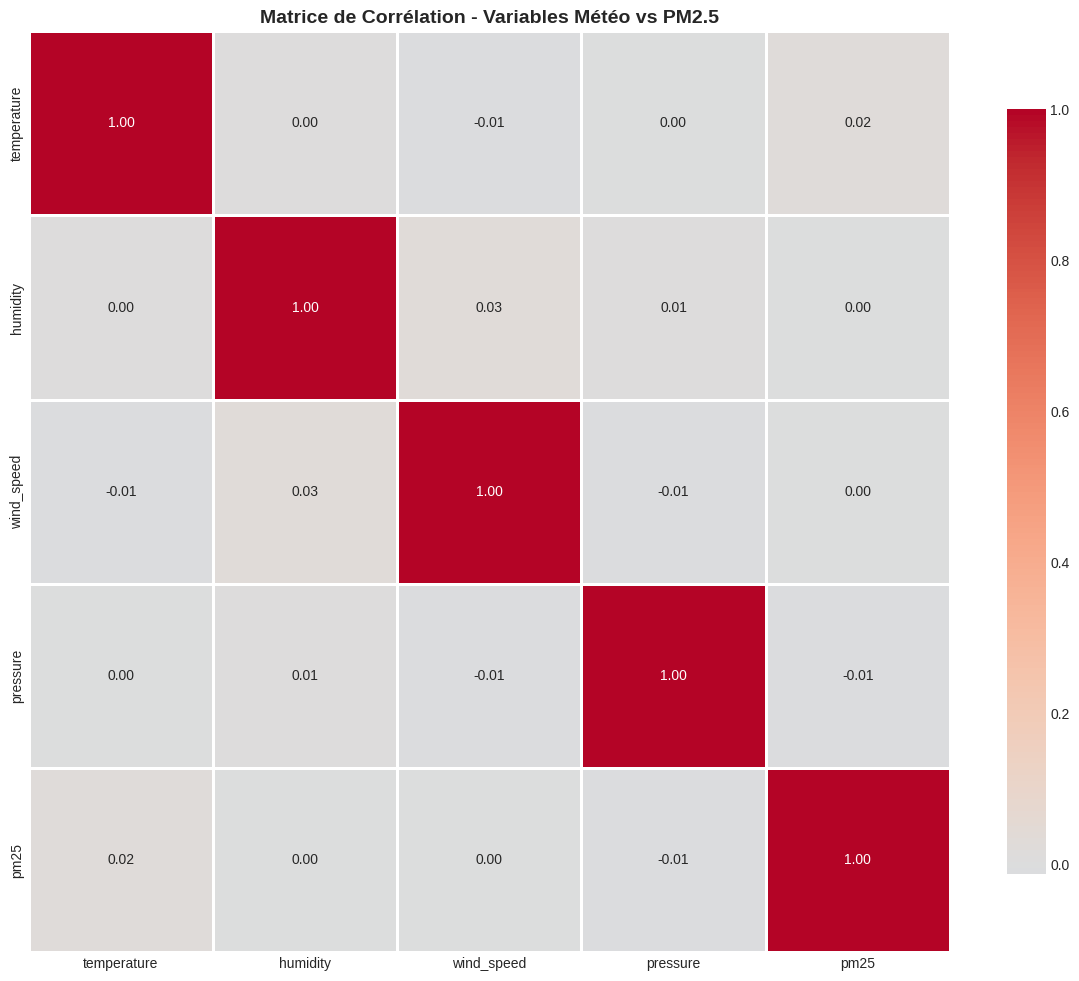


🔗 Top 10 corrélations avec pm25:
temperature    0.019637
wind_speed     0.002409
humidity       0.000393
pressure      -0.005603
Name: pm25, dtype: float64


In [ ]:
# Sélectionner uniquement les colonnes numériques
numeric_cols = df_train.select_dtypes(include=[np.number]).columns.tolist()

if len(numeric_cols) > 1:
    # Matrice de corrélation
    corr_matrix = df_train[numeric_cols].corr()

    plt.figure(figsize=(12, 10))
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                square=True, linewidths=1, cbar_kws={"shrink": 0.8})
    plt.title('Matrice de Corrélation - Variables Météo vs PM2.5', fontsize=14, weight='bold')
    plt.tight_layout()
    plt.show()

    # Top corrélations avec la cible
    if TARGET_COL in numeric_cols:
        target_corr = corr_matrix[TARGET_COL].drop(TARGET_COL).sort_values(ascending=False)
        print(f"\n🔗 Top 10 corrélations avec {TARGET_COL}:")
        print(target_corr.head(10))
else:
    print("⚠️ Pas assez de colonnes numériques pour calculer les corrélations.")

### 1.4 Analyse Temporelle (si dates disponibles)

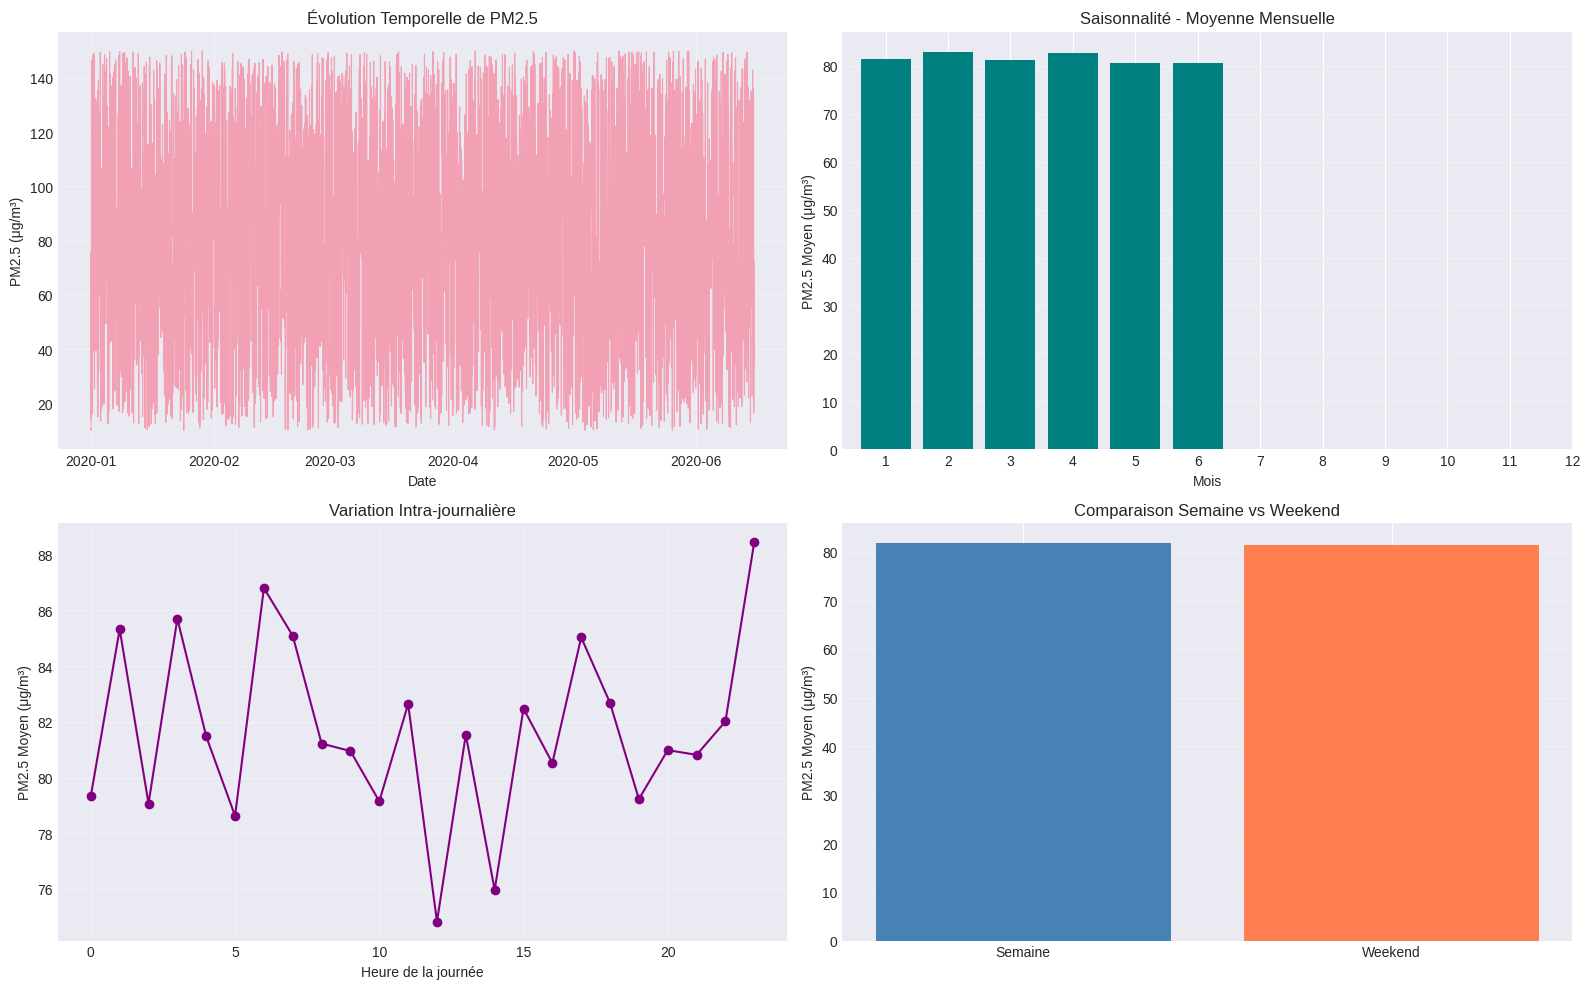

In [11]:
# Identifier la colonne de date
DATE_COL = 'date'  # À adapter

if DATE_COL in df_train.columns:
    # Conversion en datetime
    df_train[DATE_COL] = pd.to_datetime(df_train[DATE_COL])
    df_train = df_train.sort_values(DATE_COL)

    # Extraction de features temporelles
    df_train['year'] = df_train[DATE_COL].dt.year
    df_train['month'] = df_train[DATE_COL].dt.month
    df_train['day'] = df_train[DATE_COL].dt.day
    df_train['hour'] = df_train[DATE_COL].dt.hour
    df_train['dayofweek'] = df_train[DATE_COL].dt.dayofweek
    df_train['is_weekend'] = df_train['dayofweek'].isin([5, 6]).astype(int)

    if TARGET_COL in df_train.columns:
        fig, axes = plt.subplots(2, 2, figsize=(16, 10))

        # Série temporelle complète
        axes[0, 0].plot(df_train[DATE_COL], df_train[TARGET_COL], alpha=0.6, linewidth=0.8)
        axes[0, 0].set_xlabel('Date')
        axes[0, 0].set_ylabel('PM2.5 (μg/m³)')
        axes[0, 0].set_title('Évolution Temporelle de PM2.5')
        axes[0, 0].grid(alpha=0.3)

        # Variation mensuelle
        monthly_avg = df_train.groupby('month')[TARGET_COL].mean()
        axes[0, 1].bar(monthly_avg.index, monthly_avg.values, color='teal')
        axes[0, 1].set_xlabel('Mois')
        axes[0, 1].set_ylabel('PM2.5 Moyen (μg/m³)')
        axes[0, 1].set_title('Saisonnalité - Moyenne Mensuelle')
        axes[0, 1].set_xticks(range(1, 13))
        axes[0, 1].grid(alpha=0.3, axis='y')

        # Variation horaire
        hourly_avg = df_train.groupby('hour')[TARGET_COL].mean()
        axes[1, 0].plot(hourly_avg.index, hourly_avg.values, marker='o', color='purple')
        axes[1, 0].set_xlabel('Heure de la journée')
        axes[1, 0].set_ylabel('PM2.5 Moyen (μg/m³)')
        axes[1, 0].set_title('Variation Intra-journalière')
        axes[1, 0].grid(alpha=0.3)

        # Weekend vs Semaine
        weekend_data = df_train.groupby('is_weekend')[TARGET_COL].mean()
        axes[1, 1].bar(['Semaine', 'Weekend'], weekend_data.values, color=['steelblue', 'coral'])
        axes[1, 1].set_ylabel('PM2.5 Moyen (μg/m³)')
        axes[1, 1].set_title('Comparaison Semaine vs Weekend')
        axes[1, 1].grid(alpha=0.3, axis='y')

        plt.tight_layout()
        plt.show()
else:
    print(f"⚠️ Colonne date '{DATE_COL}' non trouvée. Analyse temporelle ignorée.")

## 🔧 2. FEATURE ENGINEERING

### 2.1 Création de Features Climatiques Avancées

### 2.2 Traitement des Valeurs Manquantes

## 🤖 3. MODÉLISATION BASELINE

### 3.1 Préparation des Données

### 3.2 Modèle 1: Random Forest (Baseline Simple)

### 3.3 Modèle 2: XGBoost (Avancé)

### 3.4 Comparaison des Modèles

## 📈 4. VISUALISATIONS POUR DASHBOARD

### 4.1 Heatmap Temporelle de Pollution

### 4.2 Visualisation Interactive (Plotly)

## 🚨 5. SYSTÈME D'ALERTE (BONUS)

### 5.1 Détection de Pics de Pollution

## 💾 6. GÉNÉRATION DES PRÉDICTIONS FINALES

## 📝 7. Serialisation
### 7.1 Sauvegarde du Modèle

### 7.2 Export des Visualisations

### 7.3 Notes pour le Dashboard

📌 **Le dashboard interactif est disponible séparément dans le fichier `dashboard_template.py`**

Pour l'utiliser :
1. Téléchargez le fichier `dashboard_template.py` depuis le kit
2. Installez Streamlit : `pip install streamlit`
3. Lancez : `streamlit run dashboard_template.py`

Le dashboard inclut :
- 📊 KPIs temps réel
- 📈 Graphiques interactifs Plotly
- 🔥 Heatmap jour×heure
- 🚨 Système d'alerte configurable

---

## 🎯 8. CHECKLIST FINALE POUR SOUMISSION

### Output 1: Moteur de Prédiction ✅
- [ ] Notebook documenté et exécutable de bout en bout
- [ ] Au moins 2 modèles testés (RF + XGBoost)
- [ ] Métriques de validation calculées (MAE, RMSE, R²)
- [ ] Feature engineering pertinent
- [ ] Fichier submission.csv généré

### Output 2: Dashboard Interactif 📊
- [ ] Interface Streamlit/Dash fonctionnelle
- [ ] Heatmap de pollution par jour/heure
- [ ] Courbes comparatives Météo vs PM2.5
- [ ] Indicateurs d'alerte (code couleur OMS)
- [ ] KPIs en temps réel

### Output 3: Pitch Deck & Vidéo 🎬
- [ ] 5-7 slides maximum
- [ ] Cas d'usage concret identifié
- [ ] Analyse exploratoire présentée
- [ ] Plan de déploiement réaliste
- [ ] Vidéo démo < 3 minutes

---

## 📚 Ressources Complémentaires

**Documentation:**
- [Scikit-learn Docs](https://scikit-learn.org/stable/)
- [XGBoost Docs](https://xgboost.readthedocs.io/)
- [Streamlit Gallery](https://streamlit.io/gallery)

**Datasets Complémentaires:**
- [OpenAQ](https://openaq.org) - Données mondiales de qualité de l'air
- [ECMWF](https://www.ecmwf.int) - Données météo historiques

---

## 💡 Conseils pour Optimiser Votre Score

1. **Feature Engineering avancé:**
   - Moyennes mobiles sur différentes fenêtres (3h, 6h, 12h, 24h)
   - Features d'interaction (température × humidité, vent × pression)
   - Encodage cyclique des temporalités (sin/cos)

2. **Ensemble Learning:**
   - Combinaison RF + XGBoost + LightGBM
   - Stacking avec méta-modèle
   - Blending avec pondération optimisée

3. **Validation robuste:**
   - Time Series Cross-Validation (TimeSeriesSplit)
   - Walk-forward validation
   - Backtesting sur plusieurs périodes

4. **Post-processing:**
   - Correction des prédictions négatives
   - Lissage des prédictions aberrantes
   - Contraintes physiques (min/max réalistes)

---

**Bonne chance pour le hackathon! 🚀🇨🇲**

*"L'IA n'est pas une fin en soi, mais un moyen de bâtir un avenir plus résilient pour l'Afrique."*
```